# Project 1 — Inventory Analysis

## Inventory Optimization & Replenishment Analytics

This notebook evaluates inventory efficiency, demand variability, inventory value, replenishment requirements, and stockout risk.

**Workflow:** Processed Data → Inventory Value → ABC Analysis → Inventory Turnover → Demand Variability → Safety Stock → Reorder Point → EOQ → Inventory Risk → Business Recommendations

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

products = pd.read_csv(PROCESSED_DIR / "products_clean.csv")
inventory = pd.read_csv(PROCESSED_DIR / "inventory_clean.csv")
sales = pd.read_csv(PROCESSED_DIR / "sales_clean.csv")

inventory["date"] = pd.to_datetime(inventory["date"])
sales["order_date"] = pd.to_datetime(sales["order_date"])

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")

print("\nDataset shapes:")
print(f"Products: {products.shape}")
print(f"Inventory: {inventory.shape}")
print(f"Sales: {sales.shape}")

Project root: c:\Users\HP 15\Documents\Supply-Chain-Data-Analysis
Processed data: c:\Users\HP 15\Documents\Supply-Chain-Data-Analysis\data\processed

Dataset shapes:
Products: (20, 7)
Inventory: (7300, 8)
Sales: (7300, 7)


## 2. Inventory Value Analysis

Inventory value measures the capital tied up in stock and helps identify products with significant financial exposure.

In [2]:
inventory_value = (
    inventory
    .merge(
        products[["product_id", "product_name", "category", "unit_cost"]],
        on="product_id",
        how="left"
    )
)

inventory_value["inventory_value"] = (
    inventory_value["closing_stock"]
    * inventory_value["unit_cost"]
)

product_inventory_value = (
    inventory_value
    .groupby(
        ["product_id", "product_name", "category", "unit_cost"],
        as_index=False
    )
    .agg(
        average_closing_stock=("closing_stock", "mean"),
        total_inventory_value=("inventory_value", "sum")
    )
    .sort_values(
        "total_inventory_value",
        ascending=False
    )
)

display(product_inventory_value)

,product_id,product_name,category,unit_cost,average_closing_stock,total_inventory_value
1,PROD002,Electric Motor,Equipment,320000,55.627397,6497280000
0,PROD001,Industrial Pump,Equipment,185000,48.871233,3300030000
2,PROD003,Steel Pipe,Piping,95000,93.512329,3242540000
18,PROD019,Switch Gear,Electrical,145000,58.383562,3089950000
5,PROD006,Control Valve,Components,125000,63.690411,2905875000
19,PROD020,Industrial Fan,Equipment,75000,80.024658,2190675000
17,PROD018,Electrical Cable,Electrical,28000,199.739726,2041340000
3,PROD004,PVC Pipe,Piping,42000,118.424658,1815450000
4,PROD005,Hydraulic Hose,Components,28000,145.101370,1482936000
6,PROD007,Pressure Gauge,Instrumentation,35000,99.950685,1276870000


## 3. Inventory Value by Category

This analysis aggregates inventory value by product category to identify categories with the greatest concentration of working capital.

In [3]:
category_inventory_value = (
    product_inventory_value
    .groupby("category", as_index=False)
    .agg(
        total_inventory_value=("total_inventory_value", "sum")
    )
    .sort_values(
        "total_inventory_value",
        ascending=False
    )
)

category_inventory_value["value_share"] = (
    category_inventory_value["total_inventory_value"]
    / category_inventory_value["total_inventory_value"].sum()
)

display(category_inventory_value)

,category,total_inventory_value,value_share
3,Equipment,11987985000,0.335615
1,Components,6236377500,0.174593
2,Electrical,5131290000,0.143655
6,Piping,5057990000,0.141603
0,Chemicals,2814804000,0.078803
7,Safety,2415083500,0.067613
4,Instrumentation,1276870000,0.035747
5,Packaging,799022400,0.022369


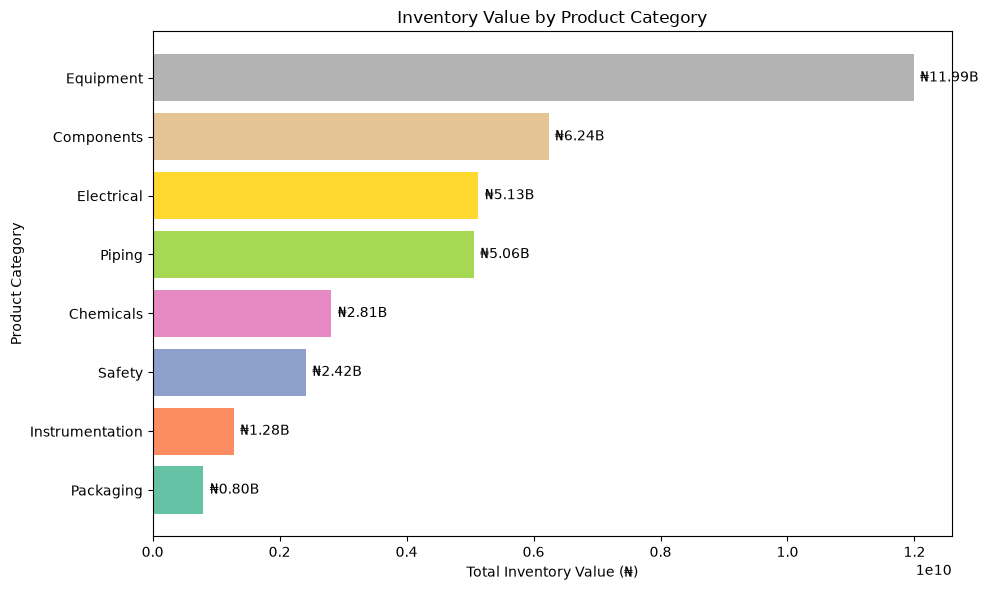

In [4]:
category_value_chart = category_inventory_value.sort_values(
    "total_inventory_value",
    ascending=True
)

plt.figure(figsize=(10, 6))

colors = plt.cm.Set2(range(len(category_value_chart)))

bars = plt.barh(
    category_value_chart["category"],
    category_value_chart["total_inventory_value"],
    color=colors
)

plt.xlabel("Total Inventory Value (₦)")
plt.ylabel("Product Category")
plt.title("Inventory Value by Product Category")

for bar, value in zip(
    bars,
    category_value_chart["total_inventory_value"]
):
    plt.text(
        bar.get_width() + 100_000_000,
        bar.get_y() + bar.get_height() / 2,
        f"₦{value / 1e9:.2f}B",
        va="center"
    )

plt.tight_layout()
plt.show()

## 4. ABC Inventory Classification

ABC analysis classifies inventory according to annual consumption value. High-value A items receive greater inventory-control attention, while C items generally require simpler control policies.

In [5]:
abc_analysis = (
    sales.groupby("product_id", as_index=False)
    .agg(
        annual_demand=("quantity_ordered", "sum")
    )
    .merge(
        products[
            ["product_id", "product_name", "category", "unit_cost"]
        ],
        on="product_id",
        how="left"
    )
)

abc_analysis["annual_consumption_value"] = (
    abc_analysis["annual_demand"]
    * abc_analysis["unit_cost"]
)

abc_analysis = abc_analysis.sort_values(
    "annual_consumption_value",
    ascending=False
).reset_index(drop=True)

abc_analysis["value_share"] = (
    abc_analysis["annual_consumption_value"]
    / abc_analysis["annual_consumption_value"].sum()
)

abc_analysis["cumulative_value_share"] = (
    abc_analysis["value_share"].cumsum()
)

abc_analysis["abc_class"] = np.select(
    [
        abc_analysis["cumulative_value_share"] <= 0.80,
        abc_analysis["cumulative_value_share"] <= 0.95
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

display(abc_analysis)

,product_id,annual_demand,product_name,category,unit_cost,annual_consumption_value,value_share,cumulative_value_share,abc_class
0,PROD002,2880,Electric Motor,Equipment,320000,921600000,0.140054,0.140054,A
1,PROD003,6310,Steel Pipe,Piping,95000,599450000,0.091098,0.231152,A
2,PROD001,3187,Industrial Pump,Equipment,185000,589595000,0.089600,0.320752,A
3,PROD019,3526,Switch Gear,Electrical,145000,511270000,0.077697,0.398448,A
4,PROD006,3965,Control Valve,Components,125000,495625000,0.075319,0.473768,A
5,PROD018,15867,Electrical Cable,Electrical,28000,444276000,0.067516,0.541284,A
6,PROD020,4742,Industrial Fan,Equipment,75000,355650000,0.054048,0.595331,A
7,PROD004,8043,PVC Pipe,Piping,42000,337806000,0.051336,0.646667,A
8,PROD005,10706,Hydraulic Hose,Components,28000,299768000,0.045555,0.692223,A
9,PROD007,8237,Pressure Gauge,Instrumentation,35000,288295000,0.043812,0.736034,A


In [6]:
abc_summary = (
    abc_analysis
    .groupby("abc_class", as_index=False)
    .agg(
        product_count=("product_id", "count"),
        consumption_value=("annual_consumption_value", "sum")
    )
)

abc_summary["value_share"] = (
    abc_summary["consumption_value"]
    / abc_summary["consumption_value"].sum()
)

abc_summary = abc_summary.sort_values("abc_class")

display(abc_summary)

,abc_class,product_count,consumption_value,value_share
0,A,11,5107731000,0.776214
1,B,5,1022335000,0.155363
2,C,4,450245000,0.068423


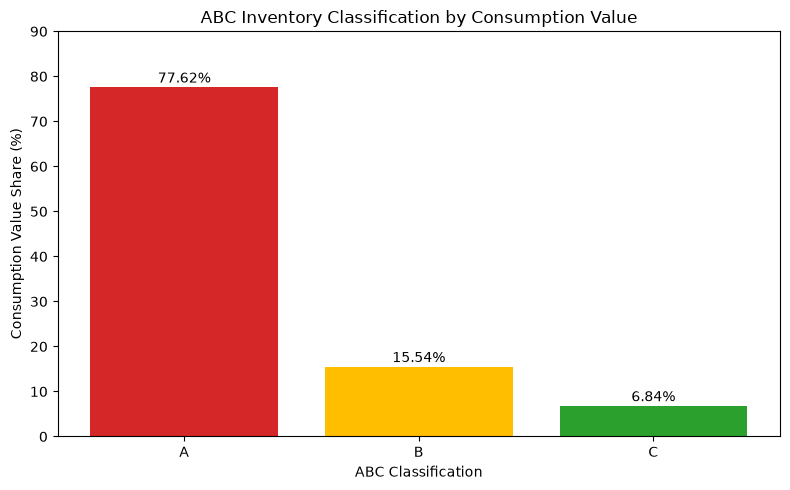

In [7]:
plt.figure(figsize=(8, 5))

colors = ["#d62728", "#ffbf00", "#2ca02c"]

bars = plt.bar(
    abc_summary["abc_class"],
    abc_summary["value_share"] * 100,
    color=colors
)

plt.xlabel("ABC Classification")
plt.ylabel("Consumption Value Share (%)")
plt.title("ABC Inventory Classification by Consumption Value")

for bar, value in zip(
    bars,
    abc_summary["value_share"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 90)
plt.tight_layout()
plt.show()

## 5. Inventory Turnover Analysis

Inventory turnover measures how efficiently inventory is converted into sales or consumed during the analysis period. A higher turnover generally indicates faster inventory movement, while a lower turnover may indicate slower-moving inventory or excess stock.

This analysis calculates:

- **COGS:** Annual demand × unit cost
- **Average Inventory Value:** Average closing inventory × unit cost
- **Inventory Turnover:** COGS ÷ Average Inventory Value
- **Days Inventory Outstanding (DIO):** 365 ÷ Inventory Turnover

The results help identify fast-moving and slow-moving products and provide evidence for inventory optimization, working-capital management, and replenishment decisions.

In [8]:
turnover_analysis = (
    inventory
    .groupby("product_id", as_index=False)
    .agg(
        average_inventory_units=("closing_stock", "mean")
    )
    .merge(
        abc_analysis[
            [
                "product_id",
                "product_name",
                "category",
                "annual_demand",
                "unit_cost"
            ]
        ],
        on="product_id",
        how="left"
    )
)

turnover_analysis["cogs"] = (
    turnover_analysis["annual_demand"]
    * turnover_analysis["unit_cost"]
)

turnover_analysis["average_inventory_value"] = (
    turnover_analysis["average_inventory_units"]
    * turnover_analysis["unit_cost"]
)

turnover_analysis["inventory_turnover"] = (
    turnover_analysis["cogs"]
    / turnover_analysis["average_inventory_value"]
)

turnover_analysis["dio"] = (
    365
    / turnover_analysis["inventory_turnover"]
)

turnover_analysis = turnover_analysis.sort_values(
    "inventory_turnover",
    ascending=False
).reset_index(drop=True)

display(turnover_analysis)

,product_id,average_inventory_units,product_name,category,annual_demand,unit_cost,cogs,average_inventory_value,inventory_turnover,dio
0,PROD012,139.290411,Safety Boots,Safety,12018,22000,264396000,3.064389e+06,86.280168,4.230404
1,PROD013,564.432877,Packaging Box,Packaging,47865,1800,86157000,1.015979e+06,84.801935,4.304147
2,PROD017,217.980822,Filter Cartridge,Components,18446,9500,175237000,2.070818e+06,84.622123,4.313293
3,PROD008,166.167123,Bearing,Components,13868,18000,249624000,2.991008e+06,83.458146,4.373450
4,PROD007,99.950685,Pressure Gauge,Instrumentation,8237,35000,288295000,3.498274e+06,82.410641,4.429040
5,PROD011,397.287671,Work Gloves,Safety,32090,3500,112315000,1.390507e+06,80.772705,4.518853
6,PROD016,116.857534,Water Treatment Chemical,Chemicals,9320,24000,223680000,2.804581e+06,79.755234,4.576502
7,PROD018,199.739726,Electrical Cable,Electrical,15867,28000,444276000,5.592712e+06,79.438379,4.594756
8,PROD010,254.326027,Safety Helmet,Safety,19888,8500,169048000,2.161771e+06,78.198839,4.667588
9,PROD015,169.457534,Cleaning Chemical,Chemicals,13178,15000,197670000,2.541863e+06,77.765796,4.693580


## 6. Inventory Turnover Visualization

This visualization compares inventory turnover across products to identify fast-moving and relatively slower-moving inventory.

Products with higher turnover generally move through inventory more frequently, while lower turnover products may require closer review of inventory levels, demand patterns, and replenishment policies.

Days Inventory Outstanding (DIO) provides a complementary measure by showing the approximate number of days inventory remains in stock based on the calculated turnover rate.

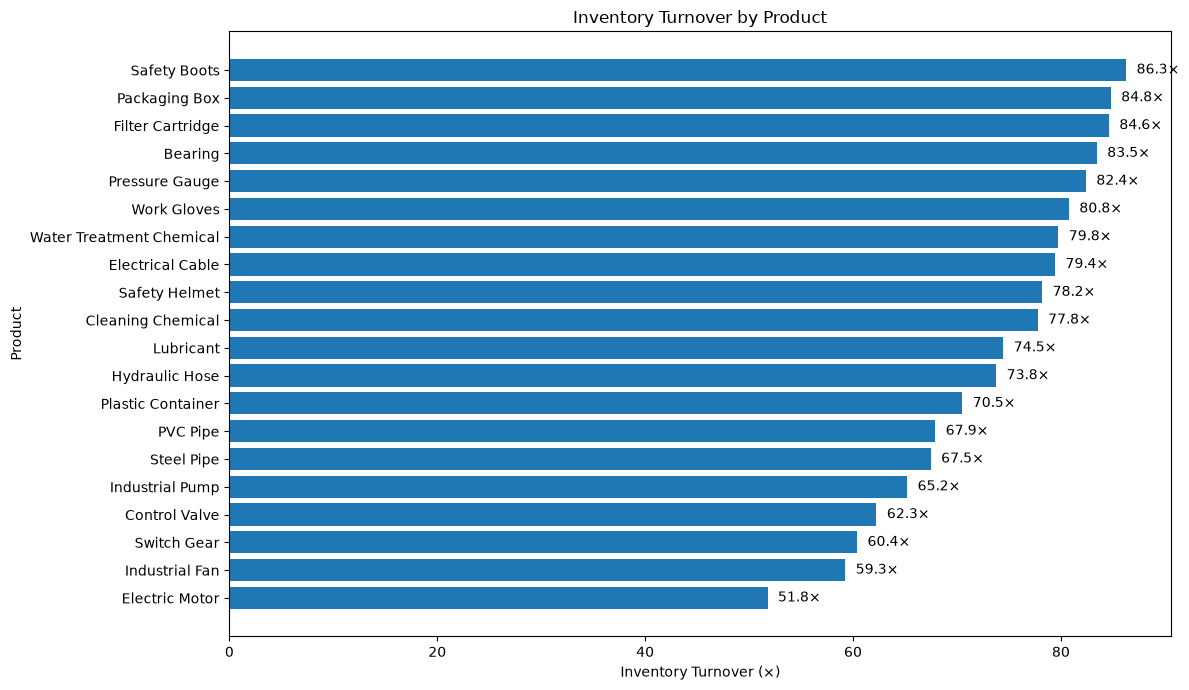

In [9]:
plt.figure(figsize=(12, 7))

turnover_plot = turnover_analysis.sort_values(
    "inventory_turnover",
    ascending=True
)

bars = plt.barh(
    turnover_plot["product_name"],
    turnover_plot["inventory_turnover"]
)

plt.xlabel("Inventory Turnover (×)")
plt.ylabel("Product")
plt.title("Inventory Turnover by Product")

for bar, value in zip(
    bars,
    turnover_plot["inventory_turnover"]
):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}×",
        va="center"
    )

plt.tight_layout()
plt.show()

## 7. Demand Variability Analysis

Demand variability measures how consistently or unpredictably product demand changes over time.

The analysis uses the **Coefficient of Variation (CV)** to compare demand variability across products with different demand volumes.

A higher CV indicates greater relative demand uncertainty and may justify additional safety-stock protection or more responsive replenishment policies.

The analysis calculates:

- **Average Daily Demand:** Mean daily demand for each product.
- **Demand Standard Deviation:** Variation in daily demand.
- **Coefficient of Variation (CV):** Demand standard deviation ÷ average daily demand.

Demand variability will be considered alongside inventory turnover, ABC classification, and stockout exposure when developing inventory-management recommendations.

In [10]:
demand_variability = (
    inventory
    .groupby("product_id", as_index=False)
    .agg(
        average_daily_demand=("demand", "mean"),
        demand_std=("demand", "std")
    )
    .merge(
        products[
            ["product_id", "product_name", "category"]
        ],
        on="product_id",
        how="left"
    )
)

demand_variability["coefficient_of_variation"] = (
    demand_variability["demand_std"]
    / demand_variability["average_daily_demand"]
)

demand_variability = demand_variability.sort_values(
    "coefficient_of_variation",
    ascending=False
).reset_index(drop=True)

display(demand_variability)

,product_id,average_daily_demand,demand_std,product_name,category,coefficient_of_variation
0,PROD002,7.890411,28.236230,Electric Motor,Equipment,3.578550
1,PROD019,9.660274,20.834768,Switch Gear,Electrical,2.156747
2,PROD016,25.534247,38.270108,Water Treatment Chemical,Chemicals,1.498776
3,PROD012,32.926027,48.536126,Safety Boots,Safety,1.474096
4,PROD010,54.487671,74.960488,Safety Helmet,Safety,1.375733
5,PROD013,131.136986,179.318315,Packaging Box,Packaging,1.367412
6,PROD015,36.104110,47.086139,Cleaning Chemical,Chemicals,1.304177
7,PROD017,50.536986,65.767839,Filter Cartridge,Components,1.301380
8,PROD011,87.917808,113.080706,Work Gloves,Safety,1.286209
9,PROD007,22.567123,28.189294,Pressure Gauge,Instrumentation,1.249131


## 8. Demand Variability Visualization

This visualization compares the coefficient of variation (CV) across products.

The CV standardizes demand variability relative to each product's average demand, making it possible to compare products with very different demand volumes.

Products with higher CV values have more unpredictable demand patterns and may require closer monitoring, flexible replenishment policies, and appropriate safety-stock protection.

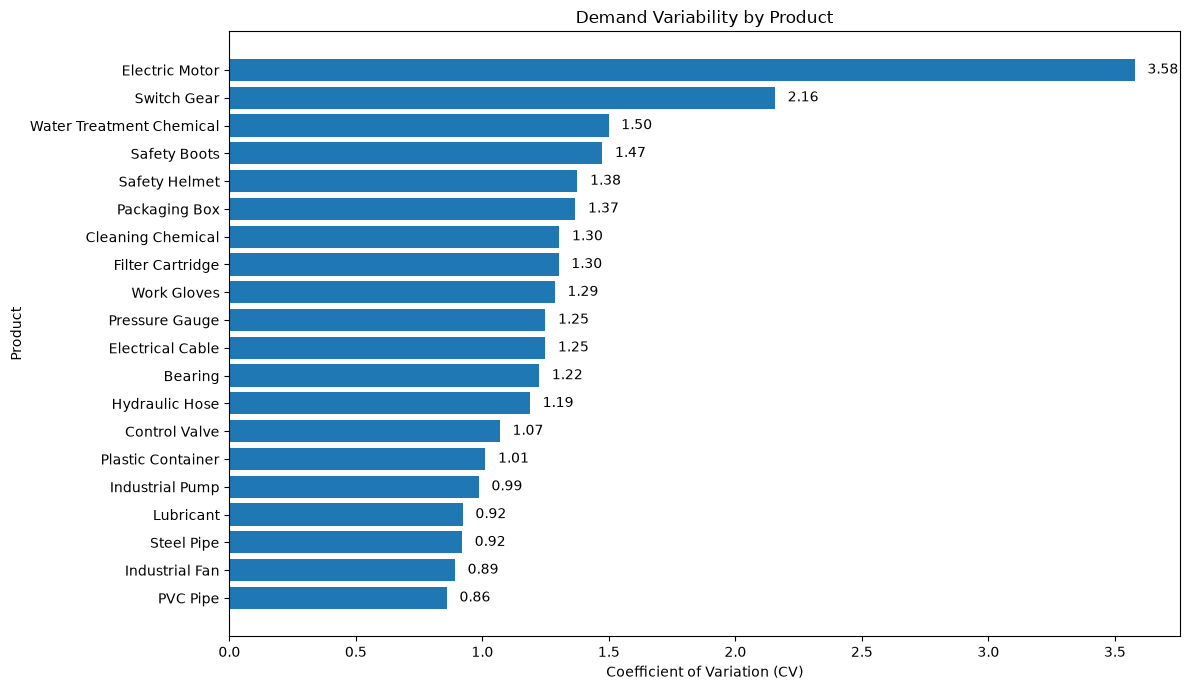

In [11]:
plt.figure(figsize=(12, 7))

variability_plot = demand_variability.sort_values(
    "coefficient_of_variation",
    ascending=True
)

bars = plt.barh(
    variability_plot["product_name"],
    variability_plot["coefficient_of_variation"]
)

plt.xlabel("Coefficient of Variation (CV)")
plt.ylabel("Product")
plt.title("Demand Variability by Product")

for bar, value in zip(
    bars,
    variability_plot["coefficient_of_variation"]
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## 9. Safety Stock Analysis

Safety stock represents additional inventory held to protect against demand uncertainty and supply lead-time variability.

For this analysis, safety stock is estimated using a **95% service-level assumption (Z = 1.645)** and the observed demand variability for each product.

The calculation incorporates:

- **Demand standard deviation:** Historical variation in daily demand.
- **Average supplier lead time:** Historical supplier delivery lead time for the product's assigned supplier.
- **Service-level factor:** Z = 1.645, representing a 95% service-level assumption.

The resulting safety-stock estimate provides a baseline for evaluating inventory protection requirements under demand uncertainty.

> **Note:** This is a simplified safety-stock model that accounts for demand variability and average lead time. A more advanced model could incorporate lead-time variability and demand–lead-time covariance.

In [13]:
purchase_orders = pd.read_csv(
    PROCESSED_DIR / "purchase_orders_clean.csv"
)

for column in ["order_date", "expected_date", "actual_date"]:
    purchase_orders[column] = pd.to_datetime(
        purchase_orders[column]
    )

print(f"Purchase Orders: {purchase_orders.shape}")

Purchase Orders: (200, 8)


In [14]:
# Calculate historical supplier lead time
purchase_orders["lead_time_days"] = (
    purchase_orders["actual_date"]
    - purchase_orders["order_date"]
).dt.days

supplier_lead_time = (
    purchase_orders
    .groupby("supplier_id", as_index=False)
    .agg(
        average_lead_time_days=("lead_time_days", "mean")
    )
)

# Combine demand variability with product and supplier information
safety_stock_analysis = (
    demand_variability[
        [
            "product_id",
            "product_name",
            "category",
            "average_daily_demand",
            "demand_std"
        ]
    ]
    .merge(
        products[
            ["product_id", "supplier_id"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        supplier_lead_time,
        on="supplier_id",
        how="left"
    )
)

# 95% service-level assumption
Z = 1.645

safety_stock_analysis["safety_stock"] = (
    Z
    * safety_stock_analysis["demand_std"]
    * np.sqrt(
        safety_stock_analysis["average_lead_time_days"]
    )
)

safety_stock_analysis = safety_stock_analysis.sort_values(
    "safety_stock",
    ascending=False
).reset_index(drop=True)

display(safety_stock_analysis)

,product_id,product_name,category,average_daily_demand,demand_std,supplier_id,average_lead_time_days,safety_stock
0,PROD013,Packaging Box,Packaging,131.136986,179.318315,SUP001,6.863636,772.801017
1,PROD011,Work Gloves,Safety,87.917808,113.080706,SUP001,6.863636,487.339423
2,PROD014,Plastic Container,Packaging,90.657534,91.741607,SUP001,6.863636,395.375159
3,PROD017,Filter Cartridge,Components,50.536986,65.767839,SUP003,10.796610,355.486559
4,PROD015,Cleaning Chemical,Chemicals,36.104110,47.086139,SUP004,20.968750,354.686988
5,PROD010,Safety Helmet,Safety,54.487671,74.960488,SUP001,6.863636,323.054235
6,PROD018,Electrical Cable,Electrical,43.471233,54.277850,SUP003,10.796610,293.381180
7,PROD016,Water Treatment Chemical,Chemicals,25.534247,38.270108,SUP004,20.968750,288.278239
8,PROD009,Lubricant,Chemicals,40.210959,37.093243,SUP004,20.968750,279.413237
9,PROD008,Bearing,Components,37.994521,46.527080,SUP003,10.796610,251.486926


## 10. Safety Stock Visualization

This visualization compares the estimated safety-stock requirement across products.

Safety-stock requirements reflect both historical demand variability and the average lead time of the assigned supplier under a 95% service-level assumption.

Products requiring larger safety-stock buffers represent greater inventory protection requirements and should receive closer attention during replenishment planning.

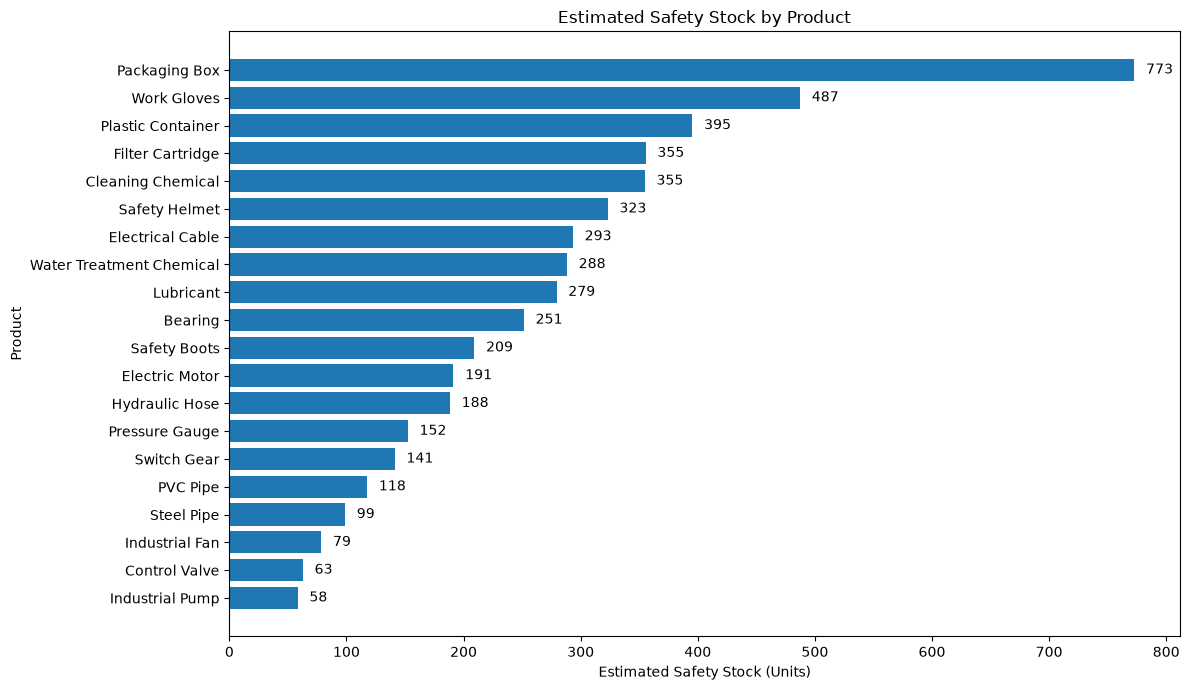

In [15]:
plt.figure(figsize=(12, 7))

safety_stock_plot = safety_stock_analysis.sort_values(
    "safety_stock",
    ascending=True
)

bars = plt.barh(
    safety_stock_plot["product_name"],
    safety_stock_plot["safety_stock"]
)

plt.xlabel("Estimated Safety Stock (Units)")
plt.ylabel("Product")
plt.title("Estimated Safety Stock by Product")

for bar, value in zip(
    bars,
    safety_stock_plot["safety_stock"]
):
    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## 11. Reorder Point (ROP) Analysis

The Reorder Point (ROP) represents the inventory level at which a replenishment order should be initiated.

The calculation combines expected demand during supplier lead time with the estimated safety-stock buffer:

**ROP = (Average Daily Demand × Average Lead Time) + Safety Stock**

Where:

- **Average Daily Demand** represents expected daily consumption.
- **Average Lead Time** represents the historical supplier lead time.
- **Safety Stock** provides protection against demand uncertainty during replenishment.

The calculated ROP provides a baseline for replenishment planning and can be compared with observed inventory levels to identify products requiring closer inventory monitoring.

In [16]:
reorder_point_analysis = safety_stock_analysis.copy()

reorder_point_analysis["cycle_stock_during_lead_time"] = (
    reorder_point_analysis["average_daily_demand"]
    * reorder_point_analysis["average_lead_time_days"]
)

reorder_point_analysis["reorder_point"] = (
    reorder_point_analysis["cycle_stock_during_lead_time"]
    + reorder_point_analysis["safety_stock"]
)

reorder_point_analysis = reorder_point_analysis.sort_values(
    "reorder_point",
    ascending=False
).reset_index(drop=True)

display(
    reorder_point_analysis[
        [
            "product_id",
            "product_name",
            "category",
            "average_daily_demand",
            "average_lead_time_days",
            "safety_stock",
            "cycle_stock_during_lead_time",
            "reorder_point"
        ]
    ]
)

,product_id,product_name,category,average_daily_demand,average_lead_time_days,safety_stock,cycle_stock_during_lead_time,reorder_point
0,PROD013,Packaging Box,Packaging,131.136986,6.863636,772.801017,900.076588,1672.877605
1,PROD009,Lubricant,Chemicals,40.210959,20.968750,279.413237,843.173545,1122.586782
2,PROD015,Cleaning Chemical,Chemicals,36.104110,20.968750,354.686988,757.058048,1111.745036
3,PROD011,Work Gloves,Safety,87.917808,6.863636,487.339423,603.435866,1090.775289
4,PROD014,Plastic Container,Packaging,90.657534,6.863636,395.375159,622.240349,1017.615508
5,PROD017,Filter Cartridge,Components,50.536986,10.796610,355.486559,545.628140,901.114700
6,PROD016,Water Treatment Chemical,Chemicals,25.534247,20.968750,288.278239,535.421233,823.699472
7,PROD018,Electrical Cable,Electrical,43.471233,10.796610,293.381180,469.341955,762.723135
8,PROD010,Safety Helmet,Safety,54.487671,6.863636,323.054235,373.983562,697.037797
9,PROD008,Bearing,Components,37.994521,10.796610,251.486926,410.212027,661.698953


## 12. Reorder Point Visualization

This visualization compares the calculated Reorder Point (ROP) across products.

The ROP represents the inventory level at which replenishment should be initiated under the assumptions used in this analysis.

Products with higher ROP values require larger inventory positions before replenishment is triggered because of their demand requirements, supplier lead times, and safety-stock requirements.

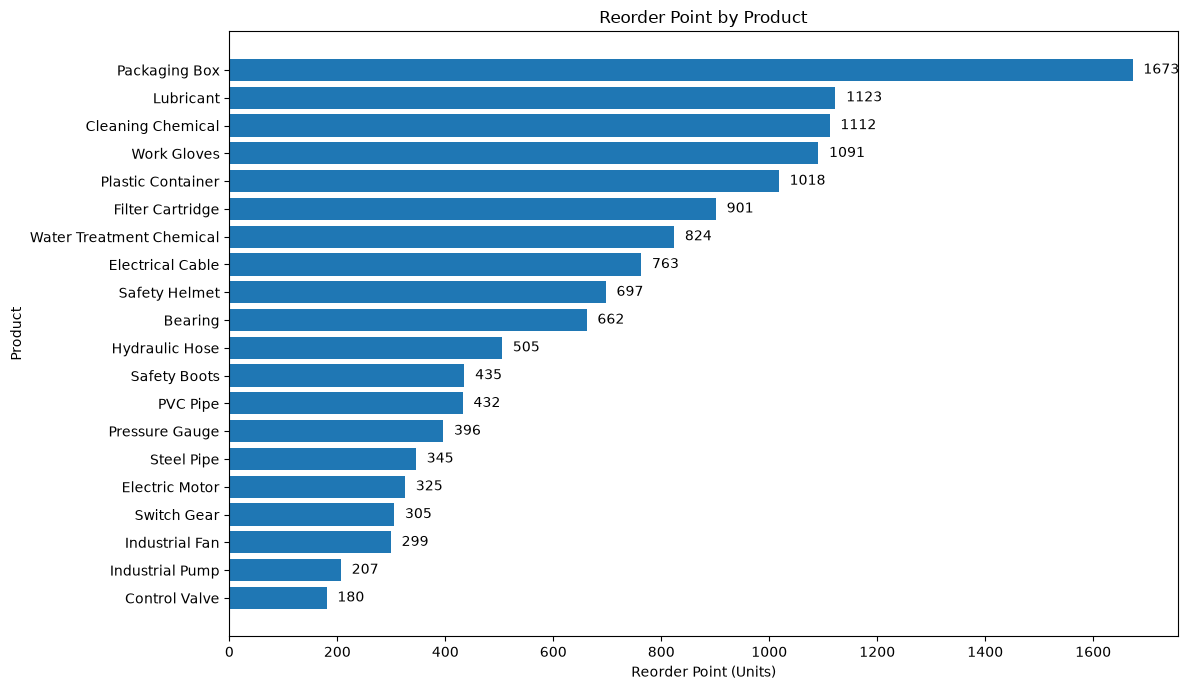

In [18]:
plt.figure(figsize=(12, 7))

rop_plot = reorder_point_analysis.sort_values(
    "reorder_point",
    ascending=True
)

bars = plt.barh(
    rop_plot["product_name"],
    rop_plot["reorder_point"]
)

plt.xlabel("Reorder Point (Units)")
plt.ylabel("Product")
plt.title("Reorder Point by Product")

for bar, value in zip(
    bars,
    rop_plot["reorder_point"]
):
    plt.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## 13. Current Inventory Position vs Reorder Point

This analysis compares each product's average observed closing inventory with its calculated Reorder Point (ROP).

The comparison helps identify products whose typical inventory position is below the modeled replenishment trigger.

The analysis calculates:

- **Average Closing Inventory:** Mean observed closing inventory during the analysis period.
- **Reorder Point:** Expected demand during supplier lead time plus safety stock.
- **Inventory Position Gap:** Average closing inventory − Reorder Point.
- **Below ROP:** Indicates whether average observed inventory is below the calculated replenishment trigger.

This comparison should be interpreted as an inventory-monitoring indicator rather than a definitive statement that a product is understocked, because actual inventory position also depends on open purchase orders, inventory in transit, demand timing, and replenishment policies.

In [19]:
inventory_position = (
    inventory
    .groupby("product_id", as_index=False)
    .agg(
        average_closing_inventory=("closing_stock", "mean")
    )
    .merge(
        reorder_point_analysis[
            [
                "product_id",
                "product_name",
                "category",
                "reorder_point"
            ]
        ],
        on="product_id",
        how="left"
    )
)

inventory_position["inventory_position_gap"] = (
    inventory_position["average_closing_inventory"]
    - inventory_position["reorder_point"]
)

inventory_position["below_rop"] = (
    inventory_position["average_closing_inventory"]
    < inventory_position["reorder_point"]
)

inventory_position = inventory_position.sort_values(
    "inventory_position_gap"
).reset_index(drop=True)

display(inventory_position)

,product_id,average_closing_inventory,product_name,category,reorder_point,inventory_position_gap,below_rop
0,PROD013,564.432877,Packaging Box,Packaging,1672.877605,-1108.444728,True
1,PROD015,169.457534,Cleaning Chemical,Chemicals,1111.745036,-942.287502,True
2,PROD009,197.112329,Lubricant,Chemicals,1122.586782,-925.474453,True
3,PROD016,116.857534,Water Treatment Chemical,Chemicals,823.699472,-706.841937,True
4,PROD011,397.287671,Work Gloves,Safety,1090.775289,-693.487618,True
5,PROD017,217.980822,Filter Cartridge,Components,901.114700,-683.133878,True
6,PROD018,199.739726,Electrical Cable,Electrical,762.723135,-562.983409,True
7,PROD014,469.249315,Plastic Container,Packaging,1017.615508,-548.366193,True
8,PROD008,166.167123,Bearing,Components,661.698953,-495.531830,True
9,PROD010,254.326027,Safety Helmet,Safety,697.037797,-442.711769,True


## 14. Inventory Position Gap Visualization

This visualization compares average closing inventory with the calculated Reorder Point for each product.

The inventory position gap is calculated as:

**Inventory Position Gap = Average Closing Inventory − Reorder Point**

Negative values indicate that average observed inventory was below the modeled reorder point during the analysis period.

This should be interpreted as a replenishment-monitoring signal rather than a definitive stockout or understocking diagnosis.

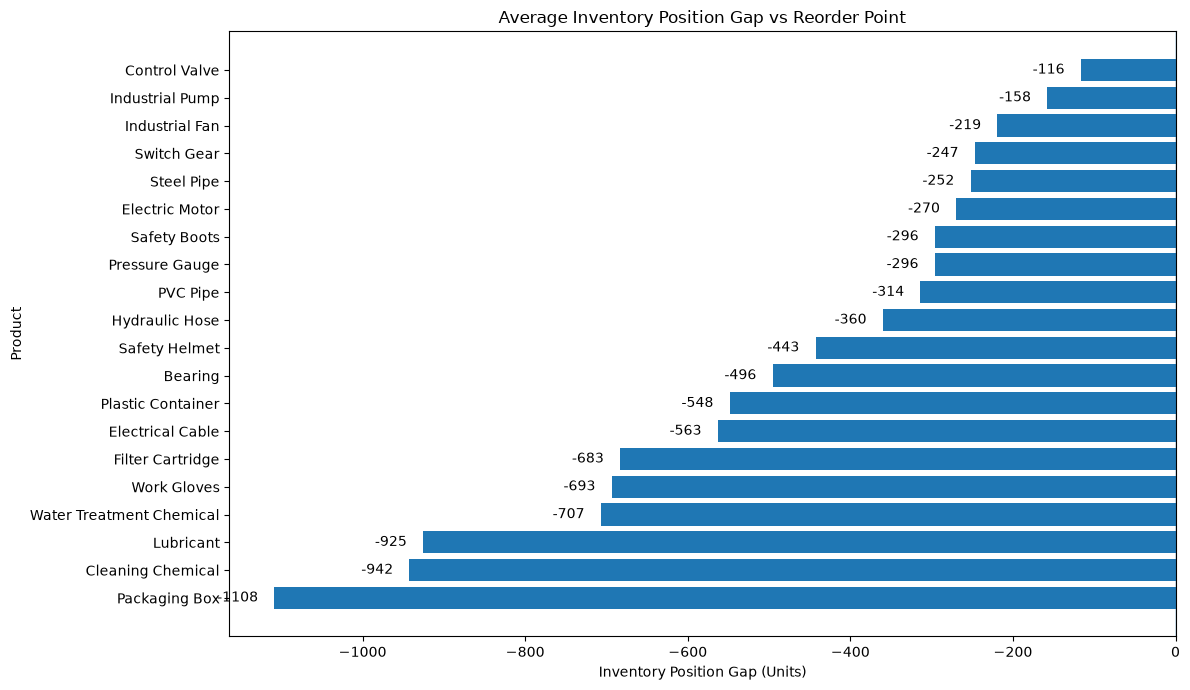

In [20]:
plt.figure(figsize=(12, 7))

gap_plot = inventory_position.sort_values(
    "inventory_position_gap",
    ascending=True
)

bars = plt.barh(
    gap_plot["product_name"],
    gap_plot["inventory_position_gap"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Inventory Position Gap (Units)")
plt.ylabel("Product")
plt.title("Average Inventory Position Gap vs Reorder Point")

for bar, value in zip(
    bars,
    gap_plot["inventory_position_gap"]
):
    plt.text(
        value - 20,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        ha="right",
        va="center"
    )

plt.tight_layout()
plt.show()

## 15. Economic Order Quantity (EOQ) Analysis

Economic Order Quantity (EOQ) estimates the optimal order quantity that balances ordering costs and inventory holding costs under a simplified set of assumptions.

The classical EOQ model is:

**EOQ = √(2DS / H)**

Where:

- **D** = annual demand
- **S** = ordering cost per order
- **H** = annual holding cost per unit

For this analysis, the following assumptions are used:

- **Ordering cost:** ₦10,000 per order
- **Annual holding-cost rate:** 20% of unit cost
- **Annual holding cost per unit:** Unit cost × 20%

The EOQ results provide a baseline order quantity for replenishment planning. In practice, order quantities may also be influenced by supplier minimum-order quantities, transportation costs, storage capacity, purchase-order constraints, and quantity discounts.

In [21]:
eoq_analysis = (
    abc_analysis[
        [
            "product_id",
            "product_name",
            "category",
            "annual_demand",
            "unit_cost"
        ]
    ]
    .copy()
)

# EOQ assumptions
ordering_cost = 10_000
holding_rate = 0.20

eoq_analysis["annual_holding_cost_per_unit"] = (
    eoq_analysis["unit_cost"]
    * holding_rate
)

eoq_analysis["eoq"] = np.sqrt(
    (
        2
        * eoq_analysis["annual_demand"]
        * ordering_cost
    )
    / eoq_analysis["annual_holding_cost_per_unit"]
)

eoq_analysis = eoq_analysis.sort_values(
    "eoq",
    ascending=False
).reset_index(drop=True)

display(eoq_analysis)

,product_id,product_name,category,annual_demand,unit_cost,annual_holding_cost_per_unit,eoq
0,PROD013,Packaging Box,Packaging,47865,1800,360.0,1630.695148
1,PROD014,Plastic Container,Packaging,33090,2500,500.0,1150.478161
2,PROD011,Work Gloves,Safety,32090,3500,700.0,957.526576
3,PROD010,Safety Helmet,Safety,19888,8500,1700.0,483.711144
4,PROD017,Filter Cartridge,Components,18446,9500,1900.0,440.645460
5,PROD009,Lubricant,Chemicals,14677,12000,2400.0,349.726083
6,PROD015,Cleaning Chemical,Chemicals,13178,15000,3000.0,296.400630
7,PROD008,Bearing,Components,13868,18000,3600.0,277.568810
8,PROD018,Electrical Cable,Electrical,15867,28000,5600.0,238.050115
9,PROD012,Safety Boots,Safety,12018,22000,4400.0,233.724780


## 16. Economic Order Quantity Visualization

This visualization compares the calculated Economic Order Quantity (EOQ) across products.

EOQ provides an estimated replenishment quantity that balances ordering and holding costs under the assumptions defined in this analysis.

The results provide a baseline for order-quantity decisions and should be evaluated alongside supplier constraints, minimum order quantities, storage capacity, transportation costs, and demand uncertainty.

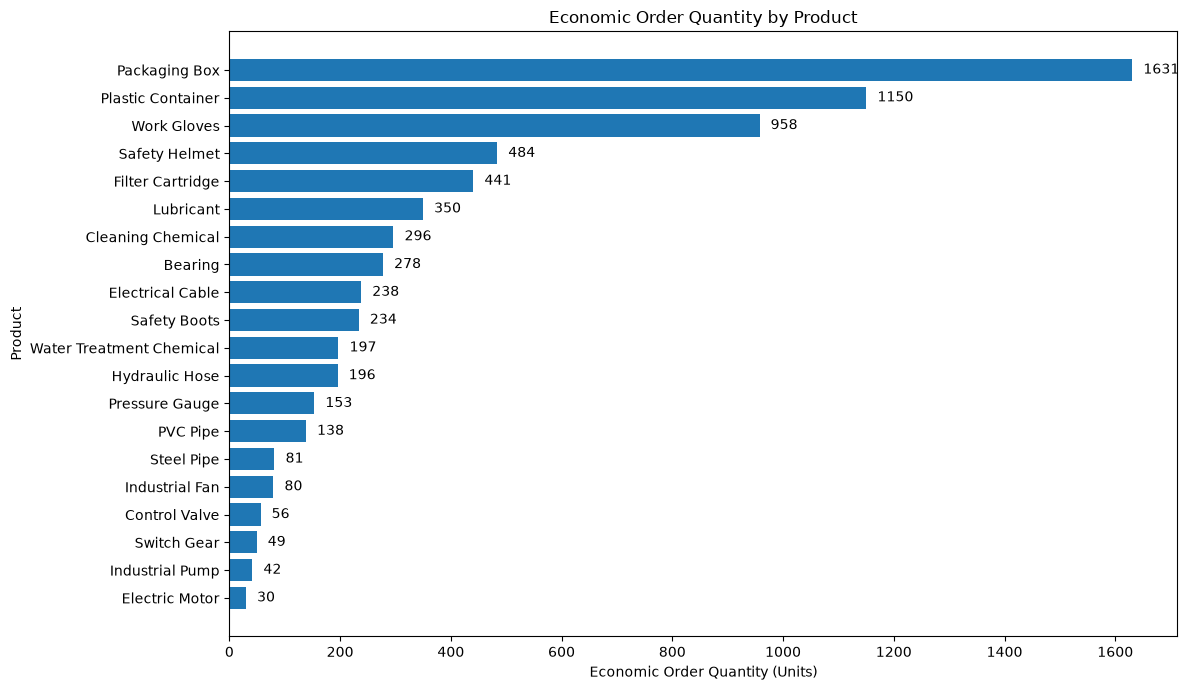

In [22]:
plt.figure(figsize=(12, 7))

eoq_plot = eoq_analysis.sort_values(
    "eoq",
    ascending=True
)

bars = plt.barh(
    eoq_plot["product_name"],
    eoq_plot["eoq"]
)

plt.xlabel("Economic Order Quantity (Units)")
plt.ylabel("Product")
plt.title("Economic Order Quantity by Product")

for bar, value in zip(
    bars,
    eoq_plot["eoq"]
):
    plt.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## 17. Inventory Risk Assessment

This analysis combines the inventory metrics developed throughout the notebook to identify products requiring closer inventory-management attention.

The assessment considers five transparent indicators:

- **ABC Class A:** High annual consumption-value exposure.
- **High Demand Variability:** Coefficient of Variation (CV) ≥ 1.50.
- **Below ROP:** Average closing inventory is below the calculated Reorder Point.
- **Low Turnover:** Inventory turnover is below the portfolio median.
- **High Safety Stock:** Estimated safety stock is above the portfolio median.

These indicators are used as screening signals rather than a definitive risk score. The purpose is to identify products that warrant further review of replenishment policies, supplier performance, demand planning, and inventory controls.

In [23]:
inventory_risk = (
    abc_analysis[
        [
            "product_id",
            "product_name",
            "category",
            "abc_class"
        ]
    ]
    .merge(
        demand_variability[
            [
                "product_id",
                "coefficient_of_variation"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        turnover_analysis[
            [
                "product_id",
                "inventory_turnover"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        safety_stock_analysis[
            [
                "product_id",
                "safety_stock"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        inventory_position[
            [
                "product_id",
                "below_rop"
            ]
        ],
        on="product_id",
        how="left"
    )
)

# Portfolio thresholds
turnover_median = inventory_risk["inventory_turnover"].median()
safety_stock_median = inventory_risk["safety_stock"].median()

inventory_risk["high_demand_variability"] = (
    inventory_risk["coefficient_of_variation"] >= 1.50
)

inventory_risk["low_turnover"] = (
    inventory_risk["inventory_turnover"]
    < turnover_median
)

inventory_risk["high_safety_stock"] = (
    inventory_risk["safety_stock"]
    > safety_stock_median
)

inventory_risk["risk_indicators"] = (
    (inventory_risk["abc_class"] == "A").astype(int)
    + inventory_risk["high_demand_variability"].astype(int)
    + inventory_risk["below_rop"].astype(int)
    + inventory_risk["low_turnover"].astype(int)
    + inventory_risk["high_safety_stock"].astype(int)
)

inventory_risk = inventory_risk.sort_values(
    ["risk_indicators", "coefficient_of_variation"],
    ascending=[False, False]
).reset_index(drop=True)

display(inventory_risk)

,product_id,product_name,category,abc_class,coefficient_of_variation,inventory_turnover,safety_stock,below_rop,high_demand_variability,low_turnover,high_safety_stock,risk_indicators
0,PROD002,Electric Motor,Equipment,A,3.578550,51.773050,191.367991,True,True,True,False,4
1,PROD019,Switch Gear,Electrical,A,2.156747,60.393712,141.205387,True,True,True,False,4
2,PROD018,Electrical Cable,Electrical,A,1.248592,79.438379,293.381180,True,False,False,True,3
3,PROD005,Hydraulic Hose,Components,A,1.188143,73.782901,188.370434,True,False,True,False,3
4,PROD006,Control Valve,Components,A,1.069100,62.254269,62.773771,True,False,True,False,3
5,PROD014,Plastic Container,Packaging,C,1.011958,70.516885,395.375159,True,False,True,True,3
6,PROD001,Industrial Pump,Equipment,A,0.985784,65.212187,58.335612,True,False,True,False,3
7,PROD009,Lubricant,Chemicals,B,0.922466,74.460081,279.413237,True,False,True,True,3
8,PROD003,Steel Pipe,Piping,A,0.919750,67.477734,98.803570,True,False,True,False,3
9,PROD020,Industrial Fan,Equipment,A,0.891660,59.256736,78.511042,True,False,True,False,3


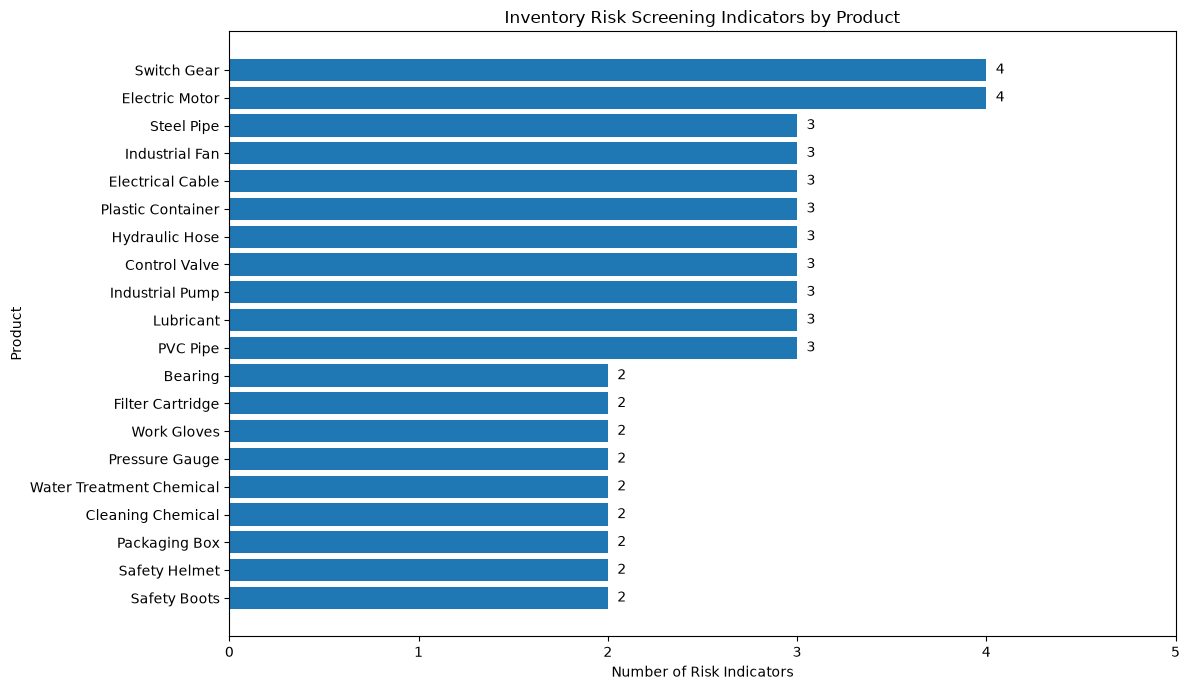

In [25]:
plt.figure(figsize=(12, 7))

risk_plot = inventory_risk.sort_values(
    "risk_indicators",
    ascending=True
)

bars = plt.barh(
    risk_plot["product_name"],
    risk_plot["risk_indicators"]
)

plt.xlabel("Number of Risk Indicators")
plt.ylabel("Product")
plt.title("Inventory Risk Screening Indicators by Product")

for bar, value in zip(
    bars,
    risk_plot["risk_indicators"]
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value}",
        va="center"
    )

plt.xticks(
    range(
        0,
        int(risk_plot["risk_indicators"].max()) + 2
    )
)

plt.tight_layout()
plt.show()

## 19. Consolidated Inventory Management Summary

This table consolidates the major inventory-management metrics developed in this notebook.

It provides a single view of demand, inventory efficiency, demand variability, replenishment requirements, and inventory-position indicators for each product.

The summary can be used as the basis for management review and subsequent inventory-policy recommendations.

In [26]:
inventory_summary = (
    abc_analysis[
        [
            "product_id",
            "product_name",
            "category",
            "annual_demand",
            "unit_cost",
            "annual_consumption_value",
            "abc_class"
        ]
    ]
    .merge(
        turnover_analysis[
            [
                "product_id",
                "inventory_turnover",
                "dio"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        demand_variability[
            [
                "product_id",
                "average_daily_demand",
                "demand_std",
                "coefficient_of_variation"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        safety_stock_analysis[
            [
                "product_id",
                "average_lead_time_days",
                "safety_stock"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        reorder_point_analysis[
            [
                "product_id",
                "reorder_point"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        inventory_position[
            [
                "product_id",
                "average_closing_inventory",
                "inventory_position_gap",
                "below_rop"
            ]
        ],
        on="product_id",
        how="left"
    )
)

inventory_summary = inventory_summary.sort_values(
    "annual_consumption_value",
    ascending=False
).reset_index(drop=True)

display(inventory_summary)

,product_id,product_name,category,annual_demand,unit_cost,annual_consumption_value,abc_class,inventory_turnover,dio,average_daily_demand,demand_std,coefficient_of_variation,average_lead_time_days,safety_stock,reorder_point,average_closing_inventory,inventory_position_gap,below_rop
0,PROD002,Electric Motor,Equipment,2880,320000,921600000,A,51.773050,7.050000,7.890411,28.236230,3.578550,16.974359,191.367991,325.302659,55.627397,-269.675262,True
1,PROD003,Steel Pipe,Piping,6310,95000,599450000,A,67.477734,5.409192,17.287671,15.900342,0.919750,14.269231,98.803570,345.485341,93.512329,-251.973012,True
2,PROD001,Industrial Pump,Equipment,3187,185000,589595000,A,65.212187,5.597113,8.731507,8.607384,0.985784,16.974359,58.335612,206.547343,48.871233,-157.676111,True
3,PROD019,Switch Gear,Electrical,3526,145000,511270000,A,60.393712,6.043676,9.660274,20.834768,2.156747,16.974359,141.205387,305.182346,58.383562,-246.798784,True
4,PROD006,Control Valve,Components,3965,125000,495625000,A,62.254269,5.863052,10.863014,11.613647,1.069100,10.796610,62.773771,180.057495,63.690411,-116.367084,True
5,PROD018,Electrical Cable,Electrical,15867,28000,444276000,A,79.438379,4.594756,43.471233,54.277850,1.248592,10.796610,293.381180,762.723135,199.739726,-562.983409,True
6,PROD020,Industrial Fan,Equipment,4742,75000,355650000,A,59.256736,6.159637,12.991781,11.584256,0.891660,16.974359,78.511042,299.038193,80.024658,-219.013536,True
7,PROD004,PVC Pipe,Piping,8043,42000,337806000,A,67.916599,5.374238,22.035616,18.938923,0.859469,14.269231,117.685093,432.116389,118.424658,-313.691732,True
8,PROD005,Hydraulic Hose,Components,10706,28000,299768000,A,73.782901,4.946946,29.331507,34.850027,1.188143,10.796610,188.370434,505.051279,145.101370,-359.949909,True
9,PROD007,Pressure Gauge,Instrumentation,8237,35000,288295000,A,82.410641,4.429040,22.567123,28.189294,1.249131,10.796610,152.368014,396.016447,99.950685,-296.065762,True


## 20. Inventory Management Recommendations

The combined inventory analysis provides several actionable findings for inventory and supply-chain management.

### 1. Prioritize high-value A-class inventory

A-class products represent the largest share of annual consumption value and should receive tighter inventory controls, more frequent review, and closer replenishment monitoring.

### 2. Strengthen replenishment monitoring

All products have average observed closing inventory below their modeled Reorder Point. This indicates that replenishment triggers should be reviewed against actual demand patterns, supplier lead times, open purchase orders, and inventory in transit.

### 3. Focus on demand variability

Electric Motor and Switch Gear have the highest coefficients of variation. Their demand patterns are relatively unpredictable and may require more responsive forecasting and safety-stock policies.

### 4. Protect high-demand products

Packaging Box, Work Gloves, Plastic Container, Filter Cartridge, and other high-demand products require close monitoring because sustained demand combined with replenishment constraints can increase stockout exposure.

### 5. Review slow-moving high-value inventory

Products with relatively low inventory turnover and high unit costs should be reviewed for excess inventory, demand uncertainty, and working-capital exposure.

### 6. Align safety stock with supply uncertainty

Safety-stock policies should consider both demand variability and supplier lead-time performance. The current model provides a baseline, but future analysis should incorporate lead-time variability and demand–lead-time covariance.

### 7. Use differentiated inventory policies

Inventory policies should not be identical across all products. ABC classification, demand variability, turnover, stockout exposure, supplier lead time, and business criticality should be considered when setting review frequencies and replenishment parameters.

### Overall management implication

The analysis indicates that inventory performance should be managed through a combination of **ABC prioritization, demand forecasting, safety-stock optimization, Reorder Point monitoring, supplier lead-time management, and stockout prevention** rather than through a single inventory metric.

## 21. Inventory Management Priority Matrix

This visualization combines demand variability and inventory turnover to identify products that may require different inventory-management approaches.

- **High variability + low turnover:** Requires closer investigation because demand is uncertain while inventory moves relatively slowly.
- **High variability + high turnover:** Requires responsive replenishment and adequate safety-stock protection.
- **Low variability + low turnover:** May require review for excess or slow-moving inventory.
- **Low variability + high turnover:** Generally supports more predictable replenishment planning.

The matrix is a screening tool and should be interpreted alongside ABC classification, stockout exposure, supplier performance, and product criticality.

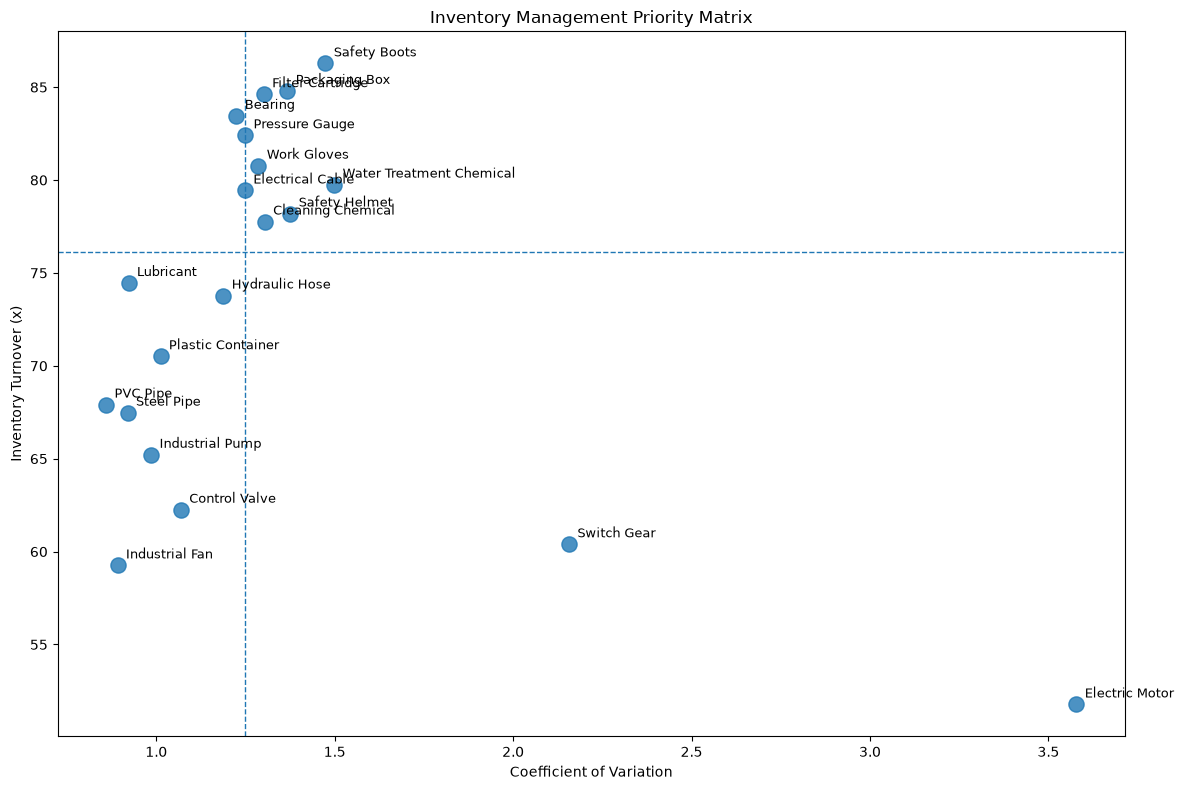

In [27]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    inventory_risk["coefficient_of_variation"],
    inventory_risk["inventory_turnover"],
    s=120,
    alpha=0.8
)

for _, row in inventory_risk.iterrows():
    plt.annotate(
        row["product_name"],
        (
            row["coefficient_of_variation"],
            row["inventory_turnover"]
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9
    )

cv_median = inventory_risk["coefficient_of_variation"].median()
turnover_median = inventory_risk["inventory_turnover"].median()

plt.axvline(
    cv_median,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    turnover_median,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Coefficient of Variation")
plt.ylabel("Inventory Turnover (x)")
plt.title(
    "Inventory Management Priority Matrix"
)

plt.tight_layout()
plt.show()

## 22. Conclusion

The inventory analysis evaluated inventory value, ABC classification, inventory turnover, demand variability, safety stock, Reorder Points, EOQ, inventory position, and inventory-risk indicators.

The analysis identified several important inventory-management signals:

- High-value A-class products require tighter inventory control and monitoring.
- Demand is concentrated across a relatively small number of products, increasing the importance of prioritizing high-demand items.
- Electric Motor and Switch Gear show particularly high demand variability and relatively lower inventory turnover.
- All products have average observed closing inventory below their modeled Reorder Point, indicating a need to review replenishment triggers and inventory-position management.
- Products with high safety-stock requirements require closer coordination between demand planning and supplier lead-time management.
- EOQ provides a quantitative baseline for order quantities, subject to practical constraints such as supplier minimum-order quantities, transportation costs, storage capacity, and purchasing policies.

Overall, the analysis demonstrates that effective inventory management requires an integrated approach combining **demand analysis, ABC classification, inventory turnover, demand variability, safety stock, Reorder Point planning, EOQ, and supplier performance**.

The results provide a foundation for subsequent supplier-performance analysis and demand forecasting.